# 07 — Tree Models & Ensemble Learning

## Objective

Our logistic regression baseline produced only weak predictive performance.

Now we want to answer:

> Is Logistic Regression simply too limited to capture the relationship
> between our SPY features and future returns, or is there very little
> predictive signal in the features themselves?

We will compare:

1. Logistic Regression — linear baseline
2. Decision Tree — nonlinear single model
3. Random Forest — bagged ensemble of trees
4. Gradient Boosting — sequential error-correcting ensemble

## Mental Model

### Decision Tree
One flexible nonlinear model.

### Random Forest
Many high-variance decision trees trained with randomness,
then aggregated to reduce variance.

### Gradient Boosting
Trees are trained sequentially, with each new tree attempting
to correct errors made by the existing ensemble.

## Important Rule

Because this is financial time-series data:

**Never randomly shuffle train and test data.**

Past → Train  
Future → Test

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/spy_modeling_data.csv")

df.head()

,Date,return_1d,return_3d,return_5d,return_10d,return_20d,price_vs_sma5,price_vs_sma20,sma5_vs_sma20,volatility_5d,volatility_20d,volatility_ratio,high_low_range,overnight_gap,intraday_return,volume_ratio,target_3d
0,1993-03-01,-0.002814,0.000706,0.012866,-0.007008,0.007824,0.001980,-0.000212,-0.002187,0.006073,0.007807,0.777961,0.007763,0.003519,-0.006311,0.242519,1.0
1,1993-03-02,0.014820,0.013389,0.028612,0.033789,0.015536,0.011109,0.013818,0.002679,0.007720,0.008328,0.927048,0.015299,0.000706,0.014104,0.703432,0.0
2,1993-03-03,0.004173,0.016186,0.019774,0.038849,0.017618,0.011346,0.017152,0.005741,0.006591,0.008357,0.788662,0.004848,0.001391,0.002778,1.064048,1.0
3,1993-03-04,-0.005540,0.013408,0.011980,0.033837,0.001394,0.003354,0.011445,0.008065,0.007884,0.008151,0.967249,0.006964,0.001385,-0.006916,0.370992,1.0
4,1993-03-05,-0.002786,-0.004172,0.007741,0.027259,-0.005556,-0.000977,0.008912,0.009899,0.008232,0.008116,1.014345,0.009078,0.001393,-0.004172,0.184613,1.0


In [4]:
df.shape

(8428, 17)

In [5]:
df.columns.tolist()

['Date',
 'return_1d',
 'return_3d',
 'return_5d',
 'return_10d',
 'return_20d',
 'price_vs_sma5',
 'price_vs_sma20',
 'sma5_vs_sma20',
 'volatility_5d',
 'volatility_20d',
 'volatility_ratio',
 'high_low_range',
 'overnight_gap',
 'intraday_return',
 'volume_ratio',
 'target_3d']

In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

feature_cols = [
    col for col in df.columns
    if col not in ["Date", "target_3d"]
]

X = df[feature_cols]
y = df["target_3d"]

split_idx = int(len(df)* 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [7]:
print("Train:", X_train.shape)
print("Test :", X_test.shape)

print()
print("Train dates:",
      df.iloc[:split_idx]["Date"].min(),
      "→",
      df.iloc[:split_idx]["Date"].max())

print("Test dates:",
      df.iloc[split_idx:]["Date"].min(),
      "→",
      df.iloc[split_idx:]["Date"].max())

print()
print("Train positive rate:", y_train.mean())
print("Test positive rate :", y_test.mean())

Train: (6742, 15)
Test : (1686, 15)

Train dates: 1993-03-01 00:00:00 → 2019-12-04 00:00:00
Test dates: 2019-12-05 00:00:00 → 2026-08-21 00:00:00

Train positive rate: 0.41456541085731236
Test positive rate : 0.46026097271648875


In [8]:
tree_clf = DecisionTreeClassifier(
    random_state=42
)

tree_clf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [9]:
tree_train_pred = tree_clf.predict(X_train)
tree_test_pred = tree_clf.predict(X_test)

tree_train_proba = tree_clf.predict_proba(X_train)[:, 1]
tree_test_proba = tree_clf.predict_proba(X_test)[:, 1]

In [10]:
print("TRAIN")
print("Accuracy:", accuracy_score(y_train, tree_train_pred))
print("ROC-AUC :", roc_auc_score(y_train, tree_train_proba))

print("\nTEST")
print("Accuracy:", accuracy_score(y_test, tree_test_pred))
print("ROC-AUC :", roc_auc_score(y_test, tree_test_proba))

TRAIN
Accuracy: 1.0
ROC-AUC : 1.0

TEST
Accuracy: 0.5136417556346382
ROC-AUC : 0.5072292398323326


In [11]:
print("Tree depth:", tree_clf.get_depth())
print("Number of leaves:", tree_clf.get_n_leaves())
print("Total nodes:", tree_clf.tree_.node_count)

Tree depth: 32
Number of leaves: 1360
Total nodes: 2719


In [16]:
dtree_small = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)

dtree_small.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [17]:
small_train_pred = dtree_small.predict(X_train)
small_test_pred = dtree_small.predict(X_test)

small_train_proba = dtree_small.predict_proba(X_train)[:, 1]
small_test_proba = dtree_small.predict_proba(X_test)[:, 1]

print("TRAIN")
print("Accuracy:", accuracy_score(y_train, small_train_pred))
print("ROC-AUC :", roc_auc_score(y_train, small_train_proba))

print("\nTEST")
print("Accuracy:", accuracy_score(y_test, small_test_pred))
print("ROC-AUC :", roc_auc_score(y_test, small_test_proba))

print("\nTree depth:", dtree_small.get_depth())
print("Leaves:", dtree_small.get_n_leaves())

TRAIN
Accuracy: 0.6173242361317116
ROC-AUC : 0.6231803507385197

TEST
Accuracy: 0.5456702253855279
ROC-AUC : 0.5392545598731167

Tree depth: 5
Leaves: 26


In [18]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [19]:
rf_train_pred = rf_clf.predict(X_train)
rf_test_pred = rf_clf.predict(X_test)

rf_train_proba = rf_clf.predict_proba(X_train)[:, 1]
rf_test_proba = rf_clf.predict_proba(X_test)[:, 1]

print("TRAIN")
print("Accuracy:", accuracy_score(y_train, rf_train_pred))
print("ROC-AUC :", roc_auc_score(y_train, rf_train_proba))

print("\nTEST")
print("Accuracy:", accuracy_score(y_test, rf_test_pred))
print("ROC-AUC :", roc_auc_score(y_test, rf_test_proba))

TRAIN
Accuracy: 1.0
ROC-AUC : 0.9999999999999999

TEST
Accuracy: 0.5516014234875445
ROC-AUC : 0.558021553189079


In [20]:
feature_importance = pd.Series(
    rf_clf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance

volatility_20d      0.074436
return_5d           0.070430
return_10d          0.069091
volatility_5d       0.068900
return_20d          0.068151
high_low_range      0.067831
volatility_ratio    0.067496
volume_ratio        0.067263
sma5_vs_sma20       0.065378
return_3d           0.065145
overnight_gap       0.064123
price_vs_sma20      0.063621
intraday_return     0.063140
price_vs_sma5       0.062817
return_1d           0.062180
dtype: float64

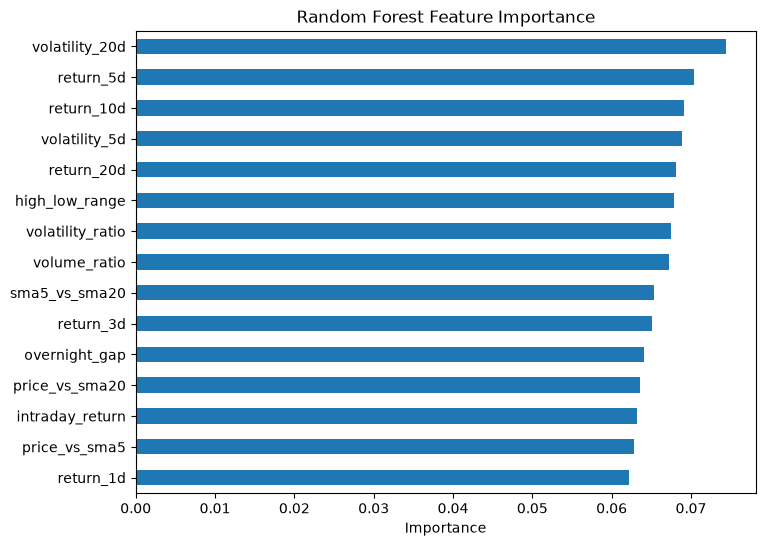

In [21]:
feature_importance.sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [22]:
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [23]:
gb_train_pred = gb_clf.predict(X_train)
gb_test_pred = gb_clf.predict(X_test)

gb_train_proba = gb_clf.predict_proba(X_train)[:, 1]
gb_test_proba = gb_clf.predict_proba(X_test)[:, 1]

In [24]:
print("TRAIN")
print("Accuracy:", accuracy_score(y_train, gb_train_pred))
print("ROC-AUC :", roc_auc_score(y_train, gb_train_proba))

print("\nTEST")
print("Accuracy:", accuracy_score(y_test, gb_test_pred))
print("ROC-AUC :", roc_auc_score(y_test, gb_test_proba))

TRAIN
Accuracy: 0.6380895876594482
ROC-AUC : 0.6924004690050141

TEST
Accuracy: 0.5533807829181495
ROC-AUC : 0.5501083323892602


In [25]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Small Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train AUC": [
        roc_auc_score(y_train, tree_train_proba),
        roc_auc_score(y_train, small_train_proba),
        roc_auc_score(y_train, rf_train_proba),
        roc_auc_score(y_train, gb_train_proba)
    ],
    "Test AUC": [
        roc_auc_score(y_test, tree_test_proba),
        roc_auc_score(y_test, small_test_proba),
        roc_auc_score(y_test, rf_test_proba),
        roc_auc_score(y_test, gb_test_proba)
    ]
})

results

,Model,Train AUC,Test AUC
0,Decision Tree,1.00000,0.507229
1,Small Decision Tree,0.62318,0.539255
2,Random Forest,1.00000,0.558022
3,Gradient Boosting,0.69240,0.550108


In [29]:
results["Overfit Gap"] = results["Train AUC"] - results["Test AUC"]

results.sort_values("Test AUC", ascending=False)

,Model,Train AUC,Test AUC,Overfit Gap
2,Random Forest,1.00000,0.558022,0.441978
3,Gradient Boosting,0.69240,0.550108,0.142292
1,Small Decision Tree,0.62318,0.539255,0.083926
0,Decision Tree,1.00000,0.507229,0.492771


## Initial Findings

- An unrestricted Decision Tree severely overfits the training data.
- Restricting tree complexity improves generalization substantially.
- Random Forest currently achieves the highest test ROC-AUC (~0.558),
  but still shows substantial overfitting.
- Gradient Boosting achieves slightly lower test ROC-AUC (~0.550),
  while exhibiting a much smaller train-test gap.

These results suggest that nonlinear relationships may contain some
predictive signal, but the signal remains weak.

Next, model hyperparameters should be evaluated using time-series
validation rather than repeatedly optimizing against the final test set.

In [30]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [37]:
rf_configs = [{
    "name": "Deep",
    "max_depth": None,
    "min_samples_leaf": 1
},
              {
    "name":"Medium",
    "max_depth": 10,
    "min_samples_leaf": 10
},
              {
    "name": "Regularized",
    "max_depth": 6,
    "min_samples_leaf":20
}
             ]

In [42]:
rf_cv_results = []

for config in rf_configs:
    fold_scores = []

    for train_idx, val_idx in tscv.split(X_train):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=config["max_depth"],
            min_samples_leaf =config["min_samples_leaf"],
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_fold_train,y_fold_train)

        val_proba = model.predict_proba(X_fold_val)[:,1]

        fold_auc = roc_auc_score(
            y_fold_val,
            val_proba
        )
        
        fold_scores.append(fold_auc)

    rf_cv_results.append({
            "Model": config["name"],
            "Mean Validation AUC": np.mean(fold_scores),
            "Std Validation AUC": np.std(fold_scores),
            "Fold Scores": fold_scores
        })

In [43]:
rf_cv_df = pd.DataFrame(rf_cv_results)
rf_cv_df

,Model,Mean Validation AUC,Std Validation AUC,Fold Scores
0,Deep,0.547209,0.011794,"[0.5258460400180145, 0.5449729856706601, 0.549..."
1,Medium,0.559892,0.020720,"[0.5278775011259087, 0.5560555723346421, 0.550..."
2,Regularized,0.568690,0.024371,"[0.5324905101975166, 0.5630558072418537, 0.557..."


In [45]:
final_rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth =  6,
    min_samples_leaf = 20,
    random_state= 42,
    n_jobs=-1
)
final_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [46]:
final_test_proba = final_rf.predict_proba(X_test)[:,1]
final_test_pred = final_rf.predict(X_test)

print("FINAL TEST")
print("Accuracy:", accuracy_score(y_test, final_test_pred))
print("ROC-AUC :", roc_auc_score(y_test, final_test_proba))
print("Precision:", precision_score(y_test, final_test_pred))
print("Recall:", recall_score(y_test, final_test_pred))

FINAL TEST
Accuracy: 0.5444839857651246
ROC-AUC : 0.5579486235414071
Precision: 0.5224719101123596
Recall: 0.11984536082474227
